# Source Exclusion Robustness Tests

**Objective** — Validate that any observed sentiment–return relationship survives removing dominant sources.

**Structure:**
- **1** — Baseline: full dataset, all sources
- **2** — Cumulative top N domain exclusion (top 1, 3, 5, 10)
- **3** — Single domain drops (top 5 individually)

**Known priors from Sprint 3:**
- Top 5 domains accounted for ~42% of articles (old dataset); now 14.6% on the 2-year window
- `yahoo.com` and `fool.com` carried systematic positive bias previously
- NVDA over-represented in Yahoo (~47%) and Fool (~33%)

## 1. Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from msa.utils.paths import get_gdelt_with_sentiment, get_processed_data_path

MAG7 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA']

# Load FinBERT-scored articles
df = pd.read_parquet(get_gdelt_with_sentiment("parquet"))
df["seendate"] = pd.to_datetime(df["seendate"])

# Load joined dataset (articles + next-day OHLCV)
join = pd.read_parquet(get_processed_data_path() / "gdelt_ohlcv_join_finbert.parquet")
join["article_date"] = pd.to_datetime(join["article_date"])
join["price_date"] = pd.to_datetime(join["price_date"])

print(f"Articles: {len(df):,} rows {df['seendate'].min().date()} -> {df['seendate'].max().date()}")
print(f"Join table: {len(join):,} rows")
print(f"Unique domains: {df['domain'].nunique():,}")


Articles: 89,545 rows 2024-02-08 -> 2026-02-24
Join table: 12,523 rows
Unique domains: 5,926


### 1.1 Domain Concentration

How concentrated is article volume across domains? This tells us how much influence a small number of sources has over the dataset.

In [7]:
# Domain volume distribution
domain_counts = df["domain"].value_counts()
domain_pct = domain_counts / len(df) * 100

top10 = pd.DataFrame({
    "articles": domain_counts.head(10),
    "pct": domain_pct.head(10).round(2)
})

print("Top 10 domains by article count:")
print(top10.to_string())
print(f"\nTop 5 share:  {domain_pct.head(5).sum():.1f}%")
print(f"Top 10 share: {domain_pct.head(10).sum():.1f}%")
print(f"Single-article domains: {(domain_counts == 1).sum():,} of {len(domain_counts):,}")


Top 10 domains by article count:
                              articles   pct
domain                                      
fool.com                          3691  4.12
yahoo.com                         3478  3.88
benzinga.com                      2160  2.41
finance.yahoo.com                 1863  2.08
marketscreener.com                1778  1.99
indiatimes.com                    1765  1.97
insidermonkey.com                 1424  1.59
themarketsdaily.com                971  1.08
markets.financialcontent.com       961  1.07
webpronews.com                     910  1.02

Top 5 share:  14.5%
Top 10 share: 21.2%
Single-article domains: 1,998 of 5,926


### 1.2 Sentiment Bias by Domain

Do dominant sources carry systematically different sentiment? Investment/promotional sources were flagged in Sprint 3 as more opinionated than traditional journalism.


In [8]:
# Sentiment bias by domain (top 20 by volume)
domain_sentiment = (
    df[df["domain"].isin(domain_counts.head(20).index)]
    .groupby("domain")["sentiment_score"]
    .agg(mean="mean", median="median", count="count", std="std")
    .sort_values("count", ascending=False)
    .round(3)
)
print("Sentiment profile — top 20 domains:")
print(domain_sentiment.to_string())


Sentiment profile — top 20 domains:
                               mean  median  count    std
domain                                                   
fool.com                     -0.014  -0.006   3691  0.267
yahoo.com                    -0.050  -0.021   3478  0.130
benzinga.com                 -0.073  -0.000   2160  0.358
finance.yahoo.com             0.034   0.032   1863  0.471
marketscreener.com           -0.057  -0.007   1778  0.324
indiatimes.com               -0.062   0.009   1765  0.327
insidermonkey.com             0.011   0.004   1424  0.333
themarketsdaily.com          -0.043  -0.001    971  0.307
markets.financialcontent.com  0.093   0.053    961  0.555
webpronews.com               -0.039   0.012    910  0.399
defenseworld.net              0.000   0.007    887  0.230
dailypolitical.com           -0.051  -0.003    827  0.320
tickerreport.com             -0.030   0.004    757  0.299
cnbc.com                     -0.040  -0.015    731  0.319
wkrb13.com                   -0.084 

### 1.3 MAG7 Filter + Sentiment Threshold

Apply the threshold (|score| > 0.05) and filter to MAG7 tickers. These are the baseline article counts all exclusion tests are compared against.

In [9]:
# Apply sentiment_present threshold
df["sentiment_present"] = df["sentiment_score"].abs() > 0.05
join["sentiment_present"] = join["sentiment_score"].abs() > 0.05
join["next_day_ret"] = (join["next_close"] - join["next_open"]) / join["next_open"]

mag7_df = df[df["ticker"].isin(MAG7)].copy()
mag7_join = join[join["ticker"].isin(MAG7)].copy()

print(f"MAG7 articles: {len(mag7_df):,}")
print(f"Sentiment present: {mag7_df['sentiment_present'].sum():,} ({mag7_df['sentiment_present'].mean():.1%})")
print(f"MAG7 join rows: {len(mag7_join):,}")

MAG7 articles: 89,545
Sentiment present: 43,783 (48.9%)
MAG7 join rows: 12,523


### 1.4 Daily Coverage

How many days have sentiment-present articles across MAG7 tickers? Days with 5+ tickers is the key viability threshold for cross-sectional analysis.

In [29]:
# Daily median sentiment per ticker (baseline)
daily_sentiment = (
    mag7_join[mag7_join["sentiment_present"]]
    .groupby(["article_date", "ticker"])["sentiment_score"]
    .median()
    .reset_index()
    .rename(columns={"sentiment_score": "median_sentiment"})
)

# Daily ticker coverage
daily_coverage = daily_sentiment.groupby("article_date")["ticker"].nunique()

print("Daily sentiment coverage (baseline):")
print(f"  Total days with any sentiment: {len(daily_coverage):,}")
print(f"  Days with 5+ MAG7 tickers:    {(daily_coverage >= 5).sum():,}")
print(f"  Days with 7/7 MAG7 tickers:   {(daily_coverage == 7).sum():,}")
print(f"  Mean tickers/day:              {daily_coverage.mean():.2f}")


Daily sentiment coverage (baseline):
  Total days with any sentiment: 102
  Days with 5+ MAG7 tickers:    56
  Days with 7/7 MAG7 tickers:   48
  Mean tickers/day:              4.73


### 1.5 Visualisations


C:\Users\mathe\AppData\Local\Temp\ipykernel_39428\1231118579.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


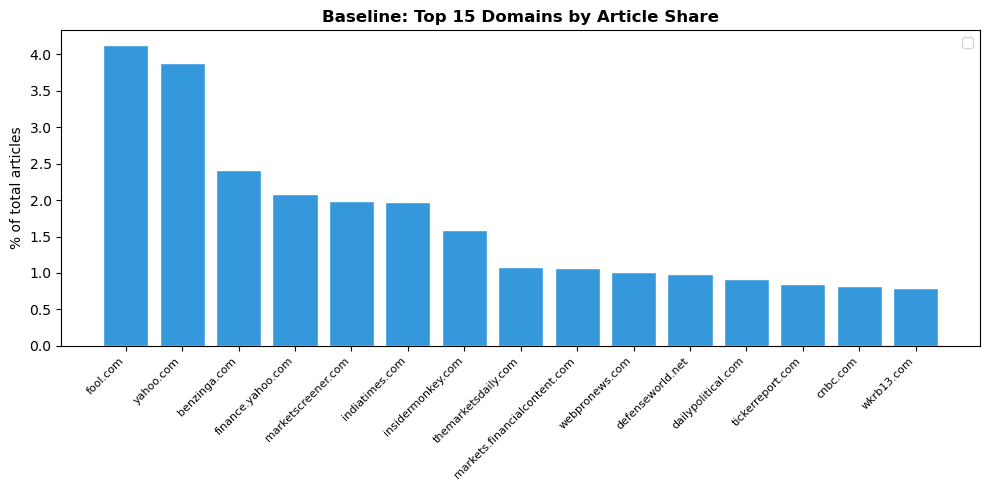

In [11]:
# Domain share bar chart
fig, ax = plt.subplots(figsize=(10, 5))
top15 = domain_pct.head(15)
ax.bar(range(len(top15)), top15.values, color="#3498db", edgecolor="white")
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% of total articles")
ax.set_title("Baseline: Top 15 Domains by Article Share", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

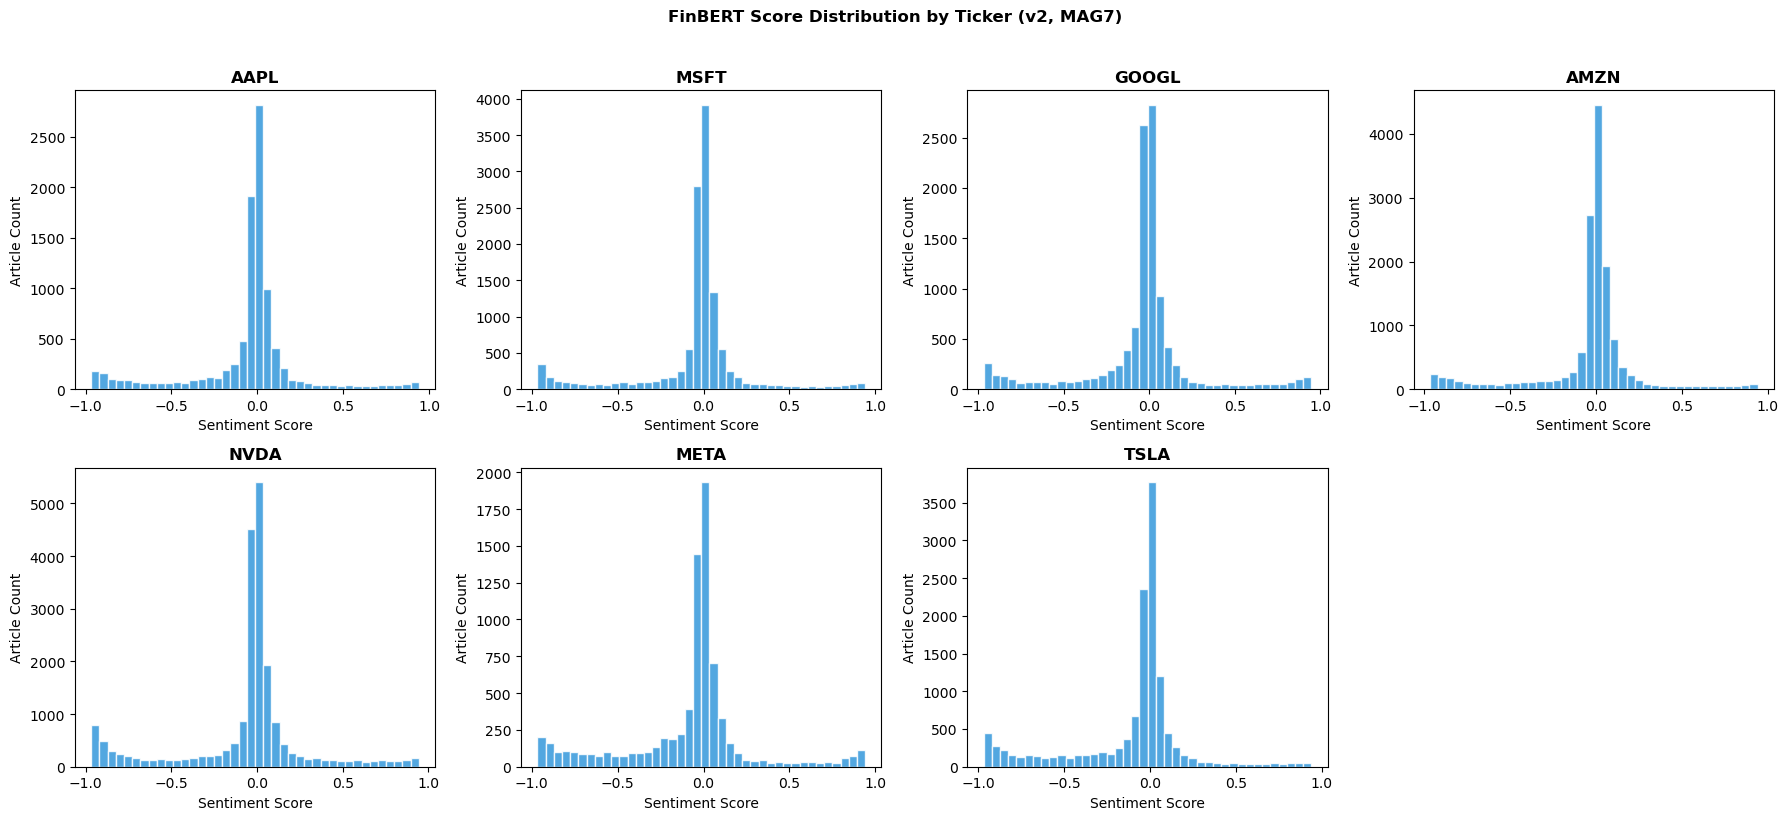

In [12]:
v2_mag7 = df[df["ticker"].isin(MAG7)].copy()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, ticker in enumerate(MAG7):
    ax = axes[i]
    scores = v2_mag7[v2_mag7["ticker"] == ticker]["sentiment_score"]
    ax.hist(scores, bins=40, color="#3498db", edgecolor="white", alpha=0.85)
    ax.set_title(ticker, fontweight="bold")
    ax.set_xlabel("Sentiment Score")
    ax.set_ylabel("Article Count")

axes[-1].set_visible(False)  # hides empty 8th slot

plt.suptitle("FinBERT Score Distribution by Ticker (v2, MAG7)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Sentiment–return correlation (baseline)
daily = (
    mag7_join[mag7_join["sentiment_present"]]
    .groupby(["article_date", "ticker"])
    .agg(
        median_sentiment=("sentiment_score", "median"),
        next_day_ret=("next_day_ret", "mean")
    )
    .reset_index()
    .dropna()
)

overall_corr = daily["median_sentiment"].corr(daily["next_day_ret"])
print(f"Baseline sentiment–return correlation (all MAG7): {overall_corr:.4f}")
print()

per_ticker = (
    daily.groupby("ticker")
    .apply(lambda g: g["median_sentiment"].corr(g["next_day_ret"]))
    .round(4)
    .rename("corr")
)
print("Per-ticker sentiment–return correlation (baseline):")
print(per_ticker.to_string())

Baseline sentiment–return correlation (all MAG7): 0.0012

Per-ticker sentiment–return correlation (baseline):
ticker
AAPL    -0.1367
AMZN     0.0419
GOOGL    0.0258
META     0.0504
MSFT    -0.2160
NVDA    -0.1268
TSLA     0.1449


C:\Users\mathe\AppData\Local\Temp\ipykernel_39428\2591047196.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["median_sentiment"].corr(g["next_day_ret"]))


### 1.6 Baseline Summary Table

Per-ticker breakdown of coverage, mean sentiment, and sentiment–return correlation. This table is the direct reference for all exclusion test comparisons.


In [30]:
baseline_rows = []
for ticker in MAG7:
    t = daily[daily["ticker"] == ticker]
    baseline_rows.append({
        "ticker": ticker,
        "n_days": len(t),
        "mean_sentiment": t["median_sentiment"].mean().round(4),
        "sentiment_std": t["median_sentiment"].std().round(4),
        "sentiment_return_corr": t["median_sentiment"].corr(t["next_day_ret"]).round(4),
    })

baseline_df = pd.DataFrame(baseline_rows).set_index("ticker")
print("=== BASELINE METRICS ===")
print(baseline_df.to_string())
print(f"\nOverall corr: {overall_corr:.4f}")
print(f"Days with 5+ tickers: {(daily_coverage >= 5).sum()}")

=== BASELINE METRICS ===
        n_days  mean_sentiment  sentiment_std  sentiment_return_corr
ticker                                                              
AAPL        57          0.0868         0.2687                -0.1367
MSFT        61          0.0891         0.2472                -0.2160
GOOGL       90          0.0783         0.3009                 0.0258
AMZN        60         -0.0095         0.2868                 0.0419
NVDA        62          0.0747         0.3035                -0.1268
META        88          0.0502         0.2670                 0.0504
TSLA        64          0.0312         0.2846                 0.1449

Overall corr: 0.0012
Days with 5+ tickers: 56


## Cumulative Top N Domain Exclusion

Remove the top 1, 3, 5, and 10 domains by article volume cumulatively and recompute key metrics. Stable metrics across exclusion levels indicate the signal is not driven by dominant sources.

### 2.1 Metrics Helper Function

Reusable function to compute coverage and correlation for any filtered join table.

In [22]:
def compute_metrics(join_filtered, label):
    """Compute coverage and sentiment metrics for a given filtered join table."""
    filtered = join_filtered[join_filtered["sentiment_present"] & join_filtered["ticker"].isin(MAG7)].copy()

    # Daily median sentiment per ticker
    daily = (filtered
        .groupby(["article_date", "ticker"])
        .agg(median_sentiment=("sentiment_score", "median"),
            next_day_ret=("next_day_ret", "mean")).reset_index().dropna()
        )

    coverage = daily.groupby("article_date")["ticker"].nunique()
    overall_corr = daily["median_sentiment"].corr(daily["next_day_ret"])

    rows = []
    for ticker in MAG7:
        t = daily[daily["ticker"] == ticker]
        rows.append({
            "ticker": ticker,
            "n_days": len(t),
            "mean_sentiment": round(t["median_sentiment"].mean(), 4),
            "sentiment_return_corr": round(t["median_sentiment"].corr(t["next_day_ret"]), 4),
        })

    metrics_df = pd.DataFrame(rows).set_index("ticker")

    print(f"\n=== {label} ===")
    print(f"  Articles remaining:      {len(join_filtered):,}")
    print(f"  Days with any sentiment: {len(coverage):,}")
    print(f"  Days with 5+ tickers:   {(coverage >= 5).sum():,}")
    print(f"  Mean tickers/day:        {coverage.mean():.2f}")
    print(f"  Overall sentiment–return corr: {overall_corr:.4f}")
    print()
    print(metrics_df.to_string())

    return {
        "label": label,
        "articles": len(join_filtered),
        "days_any": len(coverage),
        "days_5plus": int((coverage >= 5).sum()),
        "mean_tickers_per_day": round(coverage.mean(), 2),
        "overall_corr": round(overall_corr, 4),
    }

In [23]:
top_domains = domain_counts.index.tolist()
exclusion_levels = [1, 3, 5, 10]
summary_rows = []

# Baseline reference
baseline_coverage = daily_sentiment.groupby("article_date")["ticker"].nunique()
baseline_daily = (
    mag7_join[mag7_join["sentiment_present"]]
    .groupby(["article_date", "ticker"])
    .agg(median_sentiment=("sentiment_score", "median"), next_day_ret=("next_day_ret", "mean"))
    .reset_index().dropna()
)
summary_rows.append({
    "label": "Baseline (all sources)",
    "articles": len(mag7_join),
    "days_any": len(baseline_coverage),
    "days_5plus": int((baseline_coverage >= 5).sum()),
    "mean_tickers_per_day": round(baseline_coverage.mean(), 2),
    "overall_corr": round(baseline_daily["median_sentiment"].corr(baseline_daily["next_day_ret"]), 4),
})

for n in exclusion_levels:
    excluded = top_domains[:n]
    filtered_join = mag7_join[~mag7_join["domain"].isin(excluded)].copy()
    label = f"Drop top {n} domain{'s' if n > 1 else ''} ({', '.join(excluded[:2])}{'...' if n > 2 else ''})"
    result = compute_metrics(filtered_join, label)
    summary_rows.append(result)


=== Drop top 1 domain (fool.com) ===
  Articles remaining:      11,364
  Days with any sentiment: 100
  Days with 5+ tickers:   55
  Mean tickers/day:        4.76
  Overall sentiment–return corr: 0.0022

        n_days  mean_sentiment  sentiment_return_corr
ticker                                               
AAPL        57          0.0845                -0.1777
MSFT        61          0.0889                -0.2272
GOOGL       89          0.0594                 0.0732
AMZN        60         -0.0155                 0.0166
NVDA        60          0.0329                -0.1176
META        86          0.0204                 0.0471
TSLA        63          0.0178                 0.1390

=== Drop top 3 domains (fool.com, yahoo.com...) ===
  Articles remaining:      10,997
  Days with any sentiment: 100
  Days with 5+ tickers:   55
  Mean tickers/day:        4.76
  Overall sentiment–return corr: 0.0061

        n_days  mean_sentiment  sentiment_return_corr
ticker                             

### 2.2 Results

In [ ]:
summary_df = pd.DataFrame(summary_rows).set_index("label")
print("\n === Cumulative Domain Exclusion ===")
print(summary_df.to_string())


 Cumulative Domain Exclusion ===
                                              articles  days_any  days_5plus  mean_tickers_per_day  overall_corr
label                                                                                                           
Baseline (all sources)                           12523       102          56                  4.73        0.0012
Drop top 1 domain (fool.com)                     11364       100          55                  4.76        0.0022
Drop top 3 domains (fool.com, yahoo.com...)      10997       100          55                  4.76        0.0061
Drop top 5 domains (fool.com, yahoo.com...)       9025       100          55                  4.71        0.0182
Drop top 10 domains (fool.com, yahoo.com...)      7144       100          55                  4.68        0.0001


## Single Domain Drops (Top 5 Individually)

Remove each of the top 5 domains one at a time and recompute metrics. This identifies whether any single source is uniquely responsible for the signal pattern seen in the baseline.

In [24]:
top5_domains = domain_counts.head(5).index.tolist()
single_drop_rows = []

# Baseline reference
single_drop_rows.append({
    "label": "Baseline (all sources)",
    "articles": len(mag7_join),
    "days_any": int(len(baseline_coverage)),
    "days_5plus": int((baseline_coverage >= 5).sum()),
    "mean_tickers_per_day": round(baseline_coverage.mean(), 2),
    "overall_corr": round(baseline_daily["median_sentiment"].corr(baseline_daily["next_day_ret"]), 4),
})

for domain in top5_domains:
    filtered_join = mag7_join[mag7_join["domain"] != domain].copy()
    label = f"Drop {domain}"
    result = compute_metrics(filtered_join, label)
    single_drop_rows.append(result)


=== Drop fool.com ===
  Articles remaining:      11,364
  Days with any sentiment: 100
  Days with 5+ tickers:   55
  Mean tickers/day:        4.76
  Overall sentiment–return corr: 0.0022

        n_days  mean_sentiment  sentiment_return_corr
ticker                                               
AAPL        57          0.0845                -0.1777
MSFT        61          0.0889                -0.2272
GOOGL       89          0.0594                 0.0732
AMZN        60         -0.0155                 0.0166
NVDA        60          0.0329                -0.1176
META        86          0.0204                 0.0471
TSLA        63          0.0178                 0.1390

=== Drop yahoo.com ===
  Articles remaining:      12,490
  Days with any sentiment: 102
  Days with 5+ tickers:   56
  Mean tickers/day:        4.73
  Overall sentiment–return corr: -0.0026

        n_days  mean_sentiment  sentiment_return_corr
ticker                                               
AAPL        57          

### 3.2 Results

In [27]:
single_drop_df = pd.DataFrame(single_drop_rows).set_index("label")
print("\n=== SUMMARY: Single Domain Drops ===")
print(single_drop_df.to_string())


=== SUMMARY: Single Domain Drops ===
                         articles  days_any  days_5plus  mean_tickers_per_day  overall_corr
label                                                                                      
Baseline (all sources)      12523       102          56                  4.73        0.0012
Drop fool.com               11364       100          55                  4.76        0.0022
Drop yahoo.com              12490       102          56                  4.73       -0.0026
Drop benzinga.com           12189       102          56                  4.73        0.0151
Drop finance.yahoo.com      10705       102          56                  4.70        0.0175
Drop marketscreener.com     12369       102          55                  4.72        0.0183
